<a href="https://colab.research.google.com/github/bhavananamburi/oasis-infobyte-internship-/blob/main/Bhavana_task4_Twitter_Sentiment_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sentiment Analysis**



**Loading the Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Twitter_Data.csv to Twitter_Data (4).csv


In [ ]:
df = pd.read_csv("Twitter_Data.csv")

**Exploring the Dataset**

In [ ]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [ ]:
df.describe()

,category
count,162973.000000
mean,0.225436
std,0.781279
min,-1.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


**Checking for Missing Values and Duplicate Records**

In [ ]:
df.isnull().sum()

,0
clean_text,4
category,7


In [ ]:
df.duplicated().sum()

np.int64(1)

**Removing Duplicate Records**

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

print("Duplicate Rows After Cleaning:", df.duplicated().sum())

Missing Values After Cleaning:
clean_text    0
category      0
dtype: int64
Duplicate Rows After Cleaning: 0


**Sentiment Distribution**

In [ ]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


In [ ]:
import plotly.express as px
df["Sentiment"] = df["category"].replace({
    -1: "Negative",
     0: "Neutral",
     1: "Positive"
})
count = df["Sentiment"].value_counts().reset_index()
count.columns = ["Sentiment", "Count"]

fig = px.bar(
    count,
    x="Sentiment",
    y="Count",
    color="Sentiment",
    text="Count",
    color_discrete_map={
        "Positive": "#FF69B4",
        "Neutral": "#FFD6E8",
        "Negative": "#C77DFF"
    },
    title="<b> Sentiment Distribution</b>"
)

fig.update_traces(textposition="outside")

fig.update_layout(
    paper_bgcolor="#FFF5F7",
    plot_bgcolor="#FFF5F7",
    showlegend=False
)

fig.show()

In [ ]:
print(df.columns)

Index(['clean_text', 'category', 'Sentiment'], dtype='object')


**Text Preprocessing**

In [ ]:
import re
def clean_text(text):

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)

    return text

In [ ]:
df["clean_text"] = df["clean_text"].astype(str).apply(clean_text)

**Data Preparation and Train-Test Split**

In [ ]:
df = df.dropna(subset=["clean_text", "category"])
df["category"] = pd.to_numeric(df["category"], errors="coerce")
df = df.dropna(subset=["category"])

X = df["clean_text"]
y = df["category"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Building the Sentiment Classification Model**


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("classifier", MultinomialNB())
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(stop_words='english')),
                ('classifier', MultinomialNB())])

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.575934221022274

**Classification Report**

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose().round(2)

styled_report = (
    report_df.style
    .background_gradient(cmap="RdPu")
    .set_caption("Classification Report")
    .set_table_styles([
        {'selector':'caption',
         'props':[('font-size','16px'),
                  ('font-weight','bold'),
                  ('color','#E91E63')]},
        {'selector':'th',
         'props':[('background-color','#F8BBD0'),
                  ('color','black'),
                  ('font-weight','bold'),
                  ('text-align','center')]},
        {'selector':'td',
         'props':[('text-align','center'),
                  ('font-size','18px')]}
    ])
)

styled_report

,precision,recall,f1-score,support
-1.0,0.920000,0.140000,0.250000,7152.000000
0.0,0.850000,0.350000,0.490000,11067.000000
1.0,0.520000,0.970000,0.670000,14375.000000
accuracy,0.580000,0.580000,0.580000,0.580000
macro avg,0.760000,0.490000,0.470000,32594.000000
weighted avg,0.720000,0.580000,0.520000,32594.000000


**Confusion Matrix**

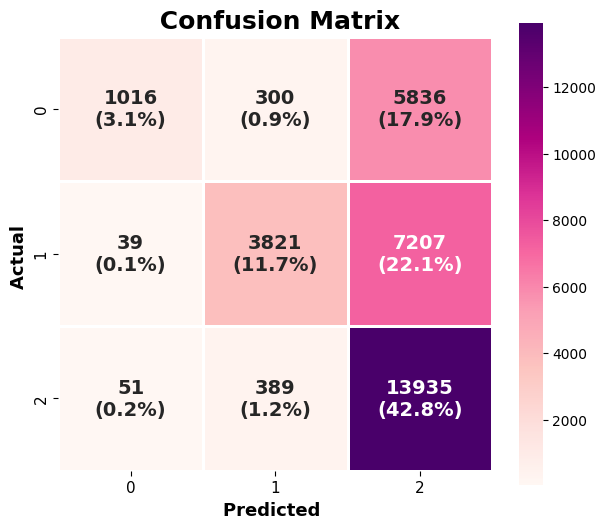

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

labels = np.asarray([
    f"{value}\n({value/cm.sum():.1%})"
    for value in cm.flatten()
]).reshape(cm.shape)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="RdPu",
    linewidths=2,
    linecolor="white",
    cbar=True,
    square=True,
    annot_kws={"fontsize":14, "fontweight":"bold"}
)

plt.title(" Confusion Matrix", fontsize=18, fontweight="bold")
plt.xlabel("Predicted ", fontsize=13, fontweight="bold")
plt.ylabel("Actual ", fontsize=13, fontweight="bold")

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

**Sentiment Percentage Distribution**

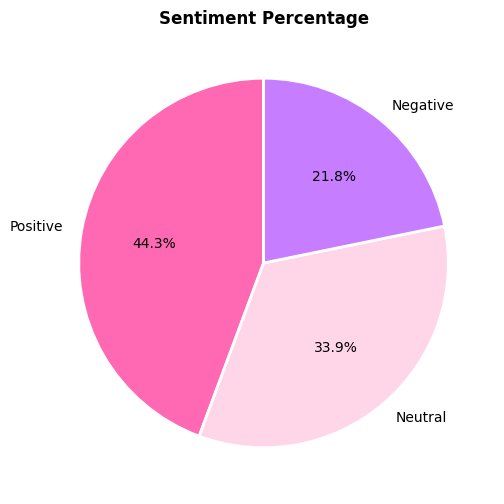

In [ ]:
colors = ["#FF69B4", "#FFD6E8", "#C77DFF"]

df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6),
    colors=colors,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.ylabel("")
plt.title("Sentiment Percentage", fontweight="bold")
plt.show()

**Test the Model with Sample Input**

In [ ]:
sample = [
    "This movie is amazing.",
    "Worst service ever."
]

predictions = model.predict(sample)

label = {-1: "Negative", 0: "Neutral", 1: "Positive"}

for text, pred in zip(sample, predictions):
    print("Tweet:", text)
    print("Predicted Sentiment:", label[pred])
    print()

Tweet: This movie is amazing.
Predicted Sentiment: Positive

Tweet: Worst service ever.
Predicted Sentiment: Negative



**Tweet Length by Sentiment**

In [ ]:
import plotly.express as px
df["Length"] = pd.cut(
    df["clean_text"].str.len(),
    bins=[0, 50, 100, 10000],
    labels=["Short", "Medium", "Long"]
)

treemap_data = (
    df.groupby(["Sentiment", "Length"])
      .size()
      .reset_index(name="Count")
)

fig = px.treemap(
    treemap_data,
    path=[px.Constant("Tweets"), "Sentiment", "Length"],
    values="Count",
    color="Sentiment",
    color_discrete_map={
        "Positive": "#FF4FA3",
        "Neutral": "#FFD6E8",
        "Negative": "#C77DFF"
    },
    title="<b>Tweet Length by Sentiment</b>"
)

fig.update_traces(
    root_color="#FFF5F7",
    textinfo="label+percent parent",
    marker=dict(line=dict(color="white", width=2))
)

fig.update_layout(
    paper_bgcolor="#FFF5F7",
    plot_bgcolor="#FFF5F7",
    width=900,
    height=500,
    margin=dict(t=50, l=20, r=20, b=20),
    font=dict(size=13, color="#4A235A")
)
fig.update_traces(marker=dict(line=dict(color="black", width=1)))
fig.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

total = len(df)
positive = (df["category"] == 1).sum()
neutral = (df["category"] == 0).sum()
negative = (df["category"] == -1).sum()

fig = make_subplots(
    rows=2, cols=3,
    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"type":"indicator"},{"type":"pie"},{"type":"bar"}]
    ],
    subplot_titles=(
        "Total","Positive","Negative",
        "Neutral","Distribution","Count"
    )
)

for i, v, c in zip(
    [1,2,3,4],
    [total, positive, negative, neutral],
    ["#FF4FA3","#FF69B4","#C77DFF","#FFB6D9"]
):
    fig.add_trace(
        go.Indicator(mode="number", value=v,
                     number={"font":{"size":38,"color":c}}),
        1 if i<4 else 2,
        i if i<4 else 1
    )

fig.add_trace(
    go.Pie(
        labels=["Positive","Neutral","Negative"],
        values=[positive,neutral,negative],
        hole=0.6,
        marker_colors=["#FF4FA3","#FFB6D9","#C77DFF"]
    ),
    2,2
)

fig.add_trace(
    go.Bar(
        x=["Positive","Neutral","Negative"],
        y=[positive,neutral,negative],
        marker_color=["#FF4FA3","#FFB6D9","#C77DFF"]
    ),
    2,3
)
fig.update_layout(
    title="<b> Twitter Sentiment Dashboard</b>",
    paper_bgcolor="#FFF5F7",
    plot_bgcolor="#FFF5F7",
    font=dict(
        family="Arial Black",
        size=14,
        color="#5A2A55"
    ),
    height=640,
    showlegend=False
)
fig.show()
